In [4]:
library(openssl)

Warning message:
"пакет 'openssl' был собран под R версии 4.5.2"


Linking to: OpenSSL 3.6.0 1 Oct 2025



### Создаём функцию для генерации истинно-случайных чисел.

In [5]:
true_random_int <- function(n, min = 0L, max = 100L) {
  stopifnot(max >= min)

  range_size <- as.integer(max - min + 1L)
  if (range_size > 256L) stop("Максимальный размер диапазона значений для 1 байта = 256. 
  Сейчас:", range_size)
  if (range_size < 1L) stop("Пустой диапазон.")
  
  limit <- floor(256 / range_size) * range_size - 1L

  out <- integer(n)
  filled <- 0L

  while (filled < n) {
    b <- as.integer(rand_bytes(4096))
    b <- b[b <= limit]

    m <- min(length(b), n - filled)

    out[(filled + 1L):(filled + m)] <- min + (b[1:m] %% range_size)
    filled <- filled + m
  }

  return(out)
}


### Создаём генеральную совокупность истинным рандомом.

In [9]:
#Миллиарда достаточно?
nu <- 100

population <- true_random_int(nu, 0, 100)

length(population)
range(population)

[1] 100

[1]   0 100

[1] 49.93

[1] 27.68008

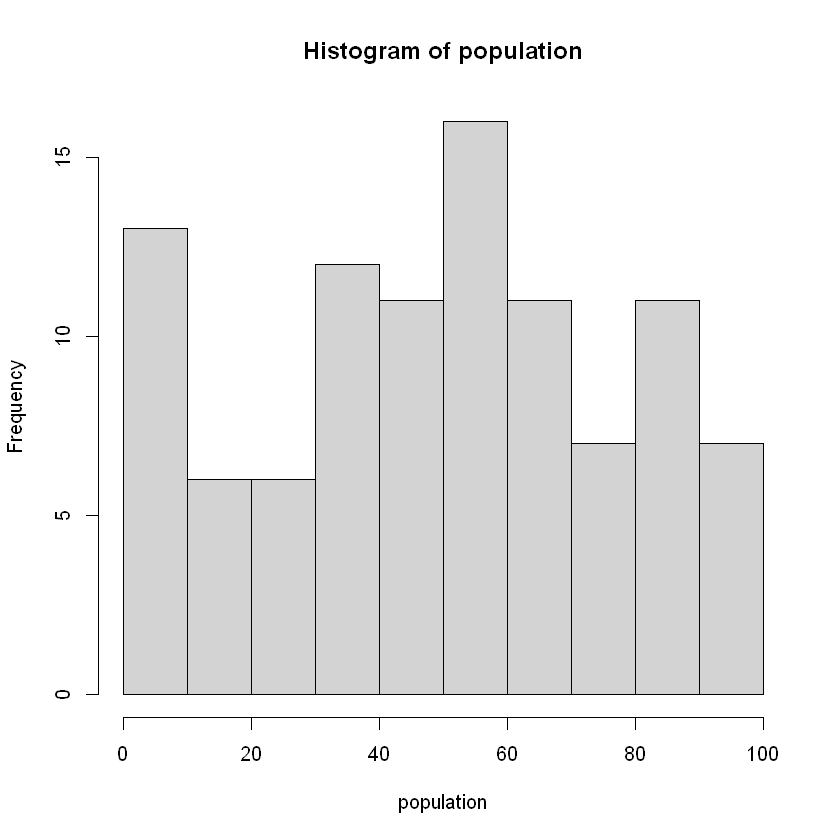

In [10]:
hist(population)

mean(population)

sd(population)